In [ ]:
# 1. Upload and load the OECD CLI dataset

from google.colab import files
import pandas as pd

# Upload Excel file
uploaded = files.upload()

# Read the Monthly sheet
df = pd.read_excel(list(uploaded.keys())[0], sheet_name="Monthly")

# Preview the dataset
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving CLI.xlsx to CLI (5).xlsx
Dataset shape: (854, 4)
Columns: ['observation_date', 'CLI', 'slope', 'phase']


,observation_date,CLI,slope,phase
0,2026-02-01,100.852506,0.190806,Expansion
1,2026-01-01,100.661700,0.195570,Expansion
2,2025-12-01,100.466130,0.173504,Expansion
3,2025-11-01,100.292626,0.140695,Expansion
4,2025-10-01,100.151931,0.104001,Expansion


Missing values by column:
observation_date    0
CLI                 0
phase               1
dtype: int64


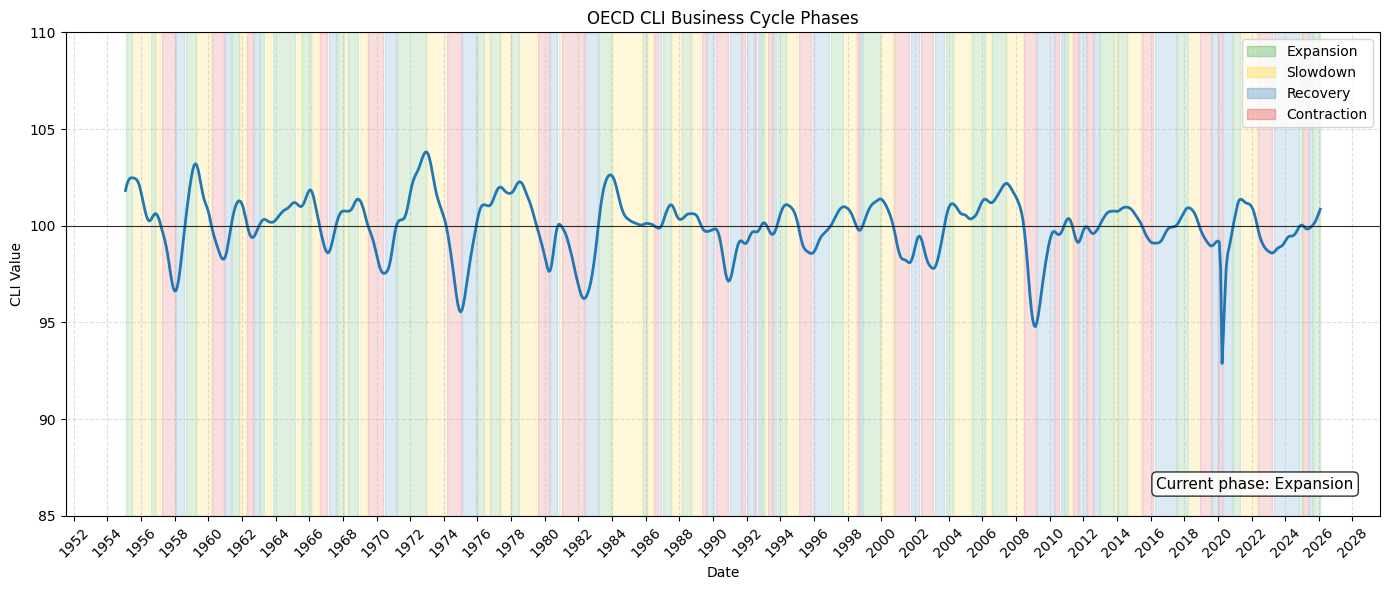

In [ ]:

# 2. Prepare and plot OECD CLI business cycle phases


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Convert date column and sort data
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df.sort_values("observation_date").reset_index(drop=True)

# Basic structure check
print("Missing values by column:")
print(df[["observation_date", "CLI", "phase"]].isna().sum())

# Keep valid rows for plotting
plot_df = df.dropna(subset=["observation_date", "CLI", "phase"]).copy()

# Define colors for each phase
colors = {
    "Expansion": "#2ca02c",
    "Slowdown": "#ffcc00",
    "Recovery": "#1f77b4",
    "Contraction": "#d62728"
}

# Check for unexpected phase labels, excluding missing values
unexpected_phases = [p for p in plot_df["phase"].unique() if p not in colors]
if unexpected_phases:
    print("\nWarning: unexpected phase labels detected:", unexpected_phases)

# Create phase groups for consecutive regime shading
plot_df["group"] = (plot_df["phase"] != plot_df["phase"].shift()).cumsum()

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot CLI series
ax.plot(plot_df["observation_date"], plot_df["CLI"], linewidth=2, label="CLI")

# Shade business cycle phases
for _, group in plot_df.groupby("group"):
    phase = group["phase"].iloc[0]

    ax.axvspan(
        group["observation_date"].iloc[0],
        group["observation_date"].iloc[-1],
        color=colors.get(phase, "grey"),
        alpha=0.15
    )

# Add current phase label
current_phase = plot_df["phase"].iloc[-1]

ax.text(
    0.98, 0.05,
    f"Current phase: {current_phase}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="bottom",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# Add legend
phase_patches = [
    Patch(color="#2ca02c", alpha=0.3, label="Expansion"),
    Patch(color="#ffcc00", alpha=0.3, label="Slowdown"),
    Patch(color="#1f77b4", alpha=0.3, label="Recovery"),
    Patch(color="#d62728", alpha=0.3, label="Contraction")
]

ax.legend(handles=phase_patches, loc="upper right")

# Format axes
ax.set_ylim(85, 110)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
ax.grid(True, linestyle="--", alpha=0.4)

ax.set_title("OECD CLI Business Cycle Phases")
ax.set_xlabel("Date")
ax.set_ylabel("CLI Value")

# Add threshold line at 100
ax.axhline(
    y=100,
    color="black",
    linewidth=0.8,
    linestyle="-",
    alpha=0.8
)

plt.tight_layout()
plt.savefig("cli_regimes.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

# 3. Descriptive statistics for CLI and slope

import pandas as pd
import numpy as np

# Keep valid observations for descriptive analysis
desc_df = df[["CLI", "slope"]].dropna().copy()

desc_stats = pd.DataFrame({
    "CLI": [
        desc_df["CLI"].count(),
        desc_df["CLI"].mean(),
        desc_df["CLI"].median(),
        desc_df["CLI"].std(),
        desc_df["CLI"].min(),
        desc_df["CLI"].quantile(0.25),
        desc_df["CLI"].quantile(0.75),
        desc_df["CLI"].max(),
        desc_df["CLI"].max() - desc_df["CLI"].min(),
        desc_df["CLI"].skew(),
        desc_df["CLI"].kurt()
    ],
    "slope": [
        desc_df["slope"].count(),
        desc_df["slope"].mean(),
        desc_df["slope"].median(),
        desc_df["slope"].std(),
        desc_df["slope"].min(),
        desc_df["slope"].quantile(0.25),
        desc_df["slope"].quantile(0.75),
        desc_df["slope"].max(),
        desc_df["slope"].max() - desc_df["slope"].min(),
        desc_df["slope"].skew(),
        desc_df["slope"].kurt()
    ]
}, index=[
    "count", "mean", "median", "std", "min",
    "25%", "75%", "max", "range", "skewness", "kurtosis"
])

print("\n=== Descriptive statistics for CLI and slope ===")
print(desc_stats.round(4))




=== Descriptive statistics for CLI and slope ===
               CLI     slope
count     853.0000  853.0000
mean       99.9971   -0.0007
median    100.1245    0.0019
std         1.4640    0.3011
min        92.8759   -4.8832
25%        99.2114   -0.1305
75%       100.9219    0.1236
max       103.8107    1.8665
range      10.9347    6.7497
skewness   -0.7201   -4.5030
kurtosis    1.5494   83.9221


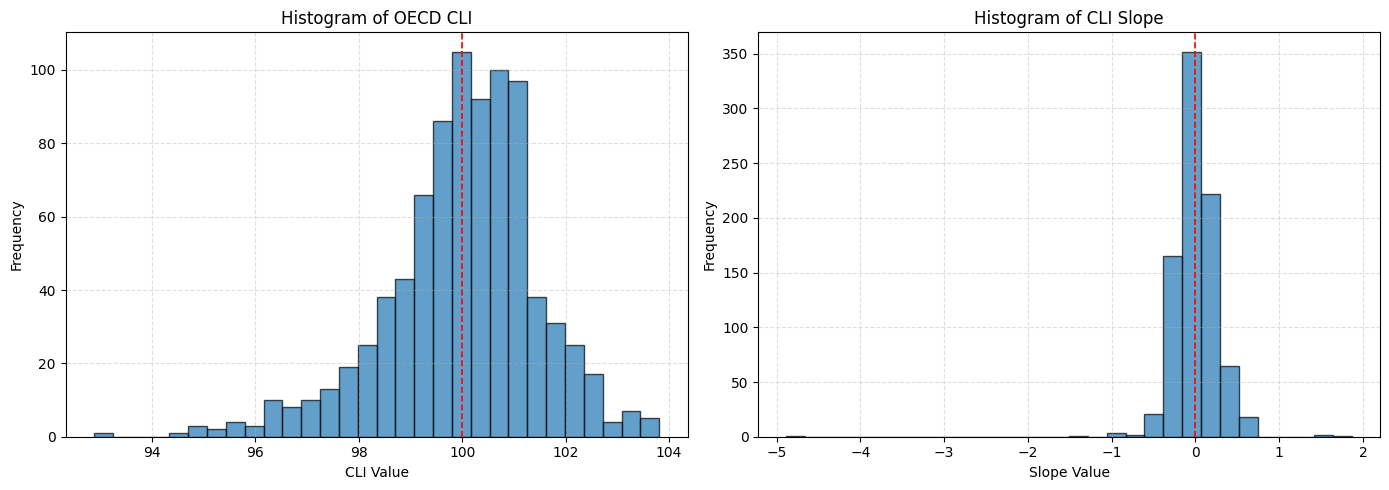

In [ ]:
# 4. Histograms for CLI and slope


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for CLI
axes[0].hist(desc_df["CLI"], bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(100, color="red", linestyle="--", linewidth=1.2)
axes[0].set_title("Histogram of OECD CLI")
axes[0].set_xlabel("CLI Value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Histogram for slope
axes[1].hist(desc_df["slope"], bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_title("Histogram of CLI Slope")
axes[1].set_xlabel("Slope Value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("cli_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
#The descriptive statistics indicate that the OECD CLI for the United States is centered very close to the neutral threshold of 100.
#The mean is 99.9971 and the median is 100.1245, which suggests that, over the full sample, the indicator oscillates around trend rather than remaining persistently in either above-trend or below-trend territory.
#The standard deviation of 1.4640 shows that the level series is relatively stable, while the observed range from 92.8759 to 103.8107 confirms that extreme deviations from trend are uncommon.

#The distribution of the CLI level is moderately left-skewed, as indicated by a skewness of -0.7201. This suggests that unusually weak cyclical conditions tend to be somewhat more pronounced than unusually strong ones.
#The positive kurtosis of 1.5494 indicates that the distribution is more peaked and has heavier tails than a normal distribution, meaning that large departures from the center occur more often than under a Gaussian benchmark.

#The slope series is centered very close to zero, with a mean of -0.0007 and a median of 0.0019.
#This is consistent with the idea that, over long periods, improvements and deteriorations in cyclical momentum broadly offset each other.
#However, the slope is much more volatile relative to its center, with a standard deviation of 0.3011 and a wide range from -4.8832 to 1.8665, indicating that monthly changes in the CLI can occasionally be abrupt.

#The distribution of the slope is strongly negatively skewed, with a skewness of -4.5030, which implies that extremely negative monthly changes are much more severe than extremely positive ones.
#This asymmetry is reinforced by the very high kurtosis of 83.9221, showing that the slope distribution is characterized by extreme tail events and sharp outliers.
#In economic terms, this suggests that deteriorations in cyclical momentum can occur in sudden and unusually large downward moves, whereas improvements tend to be more gradual.

#Overall, the descriptive evidence supports the use of both the CLI level and its slope in the phase-classification framework.
#The level captures the position of the economy relative to trend, while the slope captures cyclical momentum.
#The near-central location of both series around their respective thresholds is consistent with a business cycle framework, while the strong asymmetry and fat tails in the slope series suggest that turning points and
#downturns may be associated with disproportionately sharp negative adjustments.


=== Observations in each phase ===
             n_obs  share_%
phase                      
Expansion      239    27.99
Slowdown       223    26.11
Recovery       193    22.60
Contraction    198    23.19


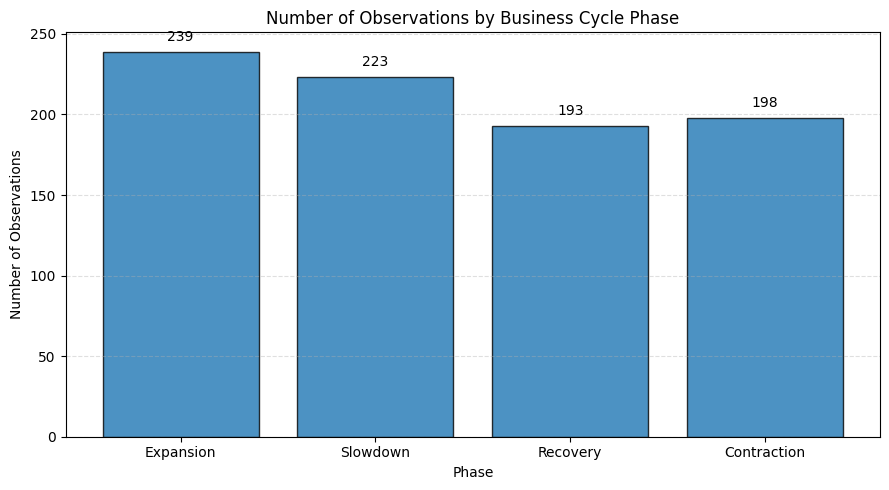

In [ ]:

# 5. Number of observations in each business cycle phase

import pandas as pd
import matplotlib.pyplot as plt

valid_phases = ["Expansion", "Slowdown", "Recovery", "Contraction"]

phase_counts = df["phase"].value_counts().reindex(valid_phases, fill_value=0)
phase_shares = (phase_counts / len(df) * 100).round(2)

phase_summary = pd.DataFrame({
    "n_obs": phase_counts,
    "share_%": phase_shares
})

print("\n=== Observations in each phase ===")
print(phase_summary)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    phase_summary.index,
    phase_summary["n_obs"],
    edgecolor="black",
    alpha=0.8
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Number of Observations by Business Cycle Phase")
ax.set_xlabel("Phase")
ax.set_ylabel("Number of Observations")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("phase_counts_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#The bar chart shows the distribution of observations across the four business cycle phases identified using the OECD CLI level and slope framework.
# Recovery is the most frequent phase in the sample, followed by contraction and expansion, while slowdown appears somewhat less often.
# This suggests that the sample contains a relatively large number of months in below-trend but improving conditions, as well as a substantial number of observations in deteriorating below-trend environments.

#The phase distribution is important because it provides context for the later asset-performance analysis.
#If some phases occur much more often than others, the average return estimates for those phases will be based on a larger number of observations and may therefore be more stable.
# Conversely, phases with fewer observations may produce results that are more sensitive to individual episodes or outliers.

In [ ]:

# 6. Observations around CLI and slope thresholds

import pandas as pd

threshold_summary = pd.DataFrame({
    "Condition": [
        "CLI >= 100",
        "CLI < 100",
        "slope > 0",
        "slope < 0",
        "CLI >= 100 and slope > 0",
        "CLI >= 100 and slope < 0",
        "CLI < 100 and slope > 0",
        "CLI < 100 and slope < 0"
    ],
    "n_obs": [
        (df["CLI"] >= 100).sum(),
        (df["CLI"] < 100).sum(),
        (df["slope"] > 0).sum(),
        (df["slope"] < 0).sum(),
        ((df["CLI"] >= 100) & (df["slope"] > 0)).sum(),
        ((df["CLI"] >= 100) & (df["slope"] < 0)).sum(),
        ((df["CLI"] < 100) & (df["slope"] > 0)).sum(),
        ((df["CLI"] < 100) & (df["slope"] < 0)).sum()
    ]
})

threshold_summary["share_%"] = (threshold_summary["n_obs"] / len(df) * 100).round(2)

print("\n=== Observations around CLI and slope thresholds ===")
print(threshold_summary)


=== Observations around CLI and slope thresholds ===
                  Condition  n_obs  share_%
0                CLI >= 100    463    54.22
1                 CLI < 100    391    45.78
2                 slope > 0    432    50.59
3                 slope < 0    421    49.30
4  CLI >= 100 and slope > 0    239    27.99
5  CLI >= 100 and slope < 0    223    26.11
6   CLI < 100 and slope > 0    193    22.60
7   CLI < 100 and slope < 0    198    23.19



=== Phase transition count matrix ===
next_phase   Expansion  Slowdown  Recovery  Contraction
phase                                                  
Expansion          207        30         0            1
Slowdown            11       193         0           19
Recovery            20         0       166            7
Contraction          0         0        27          171

=== Phase transition probability matrix ===
next_phase   Expansion  Slowdown  Recovery  Contraction
phase                                                  
Expansion        0.870     0.126     0.000        0.004
Slowdown         0.049     0.865     0.000        0.085
Recovery         0.104     0.000     0.860        0.036
Contraction      0.000     0.000     0.136        0.864


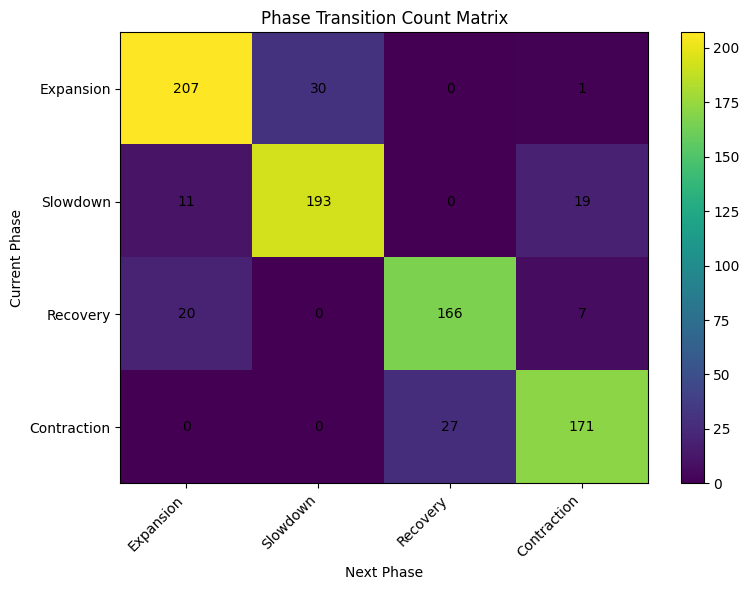

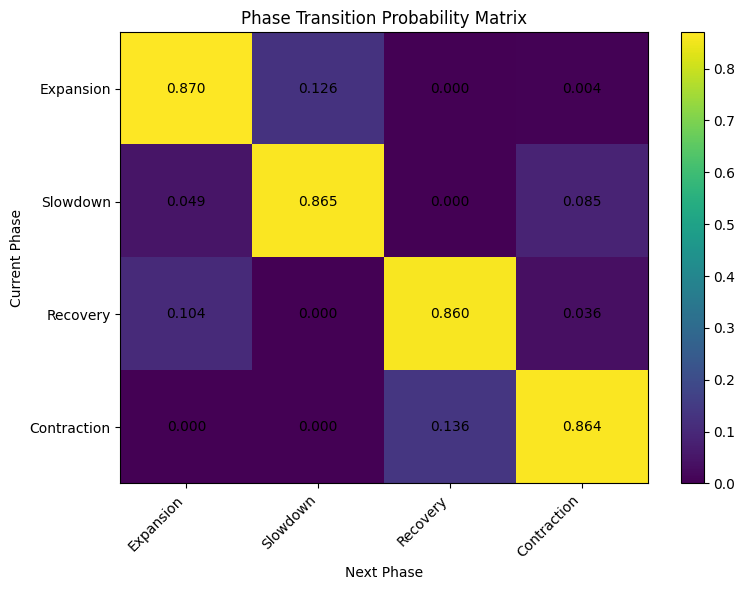

In [ ]:

# 7. Phase transition matrix

import pandas as pd
import matplotlib.pyplot as plt

valid_phases = ["Expansion", "Slowdown", "Recovery", "Contraction"]

# Create next-phase column
df["next_phase"] = df["phase"].shift(-1)

# Transition count matrix
transition_counts = pd.crosstab(
    df["phase"],
    df["next_phase"]
).reindex(index=valid_phases, columns=valid_phases, fill_value=0)

# Transition probability matrix
transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0).round(3)

print("\n=== Phase transition count matrix ===")
print(transition_counts)

print("\n=== Phase transition probability matrix ===")
print(transition_probs)


# Heatmap: transition counts

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(transition_counts.values, aspect="auto")

ax.set_xticks(range(len(valid_phases)))
ax.set_yticks(range(len(valid_phases)))
ax.set_xticklabels(valid_phases, rotation=45, ha="right")
ax.set_yticklabels(valid_phases)

for i in range(len(valid_phases)):
    for j in range(len(valid_phases)):
        ax.text(j, i, transition_counts.values[i, j],
                ha="center", va="center")

ax.set_title("Phase Transition Count Matrix")
ax.set_xlabel("Next Phase")
ax.set_ylabel("Current Phase")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("phase_transition_counts.png", dpi=300, bbox_inches="tight")
plt.show()

# Heatmap: transition probabilities

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(transition_probs.values, aspect="auto")

ax.set_xticks(range(len(valid_phases)))
ax.set_yticks(range(len(valid_phases)))
ax.set_xticklabels(valid_phases, rotation=45, ha="right")
ax.set_yticklabels(valid_phases)

for i in range(len(valid_phases)):
    for j in range(len(valid_phases)):
        ax.text(j, i, f"{transition_probs.values[i, j]:.3f}",
                ha="center", va="center")

ax.set_title("Phase Transition Probability Matrix")
ax.set_xlabel("Next Phase")
ax.set_ylabel("Current Phase")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("phase_transition_probabilities.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#The transition matrices show strong phase persistence, as all four phases have very high probabilities of remaining unchanged from one month to the next.
#The diagonal values are dominant, with transition probabilities between 0.860 and 0.870, indicating that the OECD CLI framework identifies relatively stable business cycle regimes rather than frequent random shifts.

#The off-diagonal transitions are also economically coherent. Expansion moves mainly into slowdown, slowdown is more likely to move into contraction than back into expansion, recovery tends to move into expansion,
# and contraction moves only into recovery. Direct jumps across non-adjacent phases are either absent or extremely rare.
# Overall, the transition structure supports the internal consistency and economic plausibility of the phase-classification framework.

In [ ]:

# 8. Upload and load the financial asset dataset

from google.colab import files
import pandas as pd

# Upload Excel file
uploaded_assets = files.upload()

# Read the Sheet1 sheet
assets = pd.read_excel(list(uploaded_assets.keys())[0], sheet_name="Sheet1")

# Preview the dataset
print("Dataset shape:", assets.shape)
print("Columns:", assets.columns.tolist())
assets.head()

Saving FinancialAssets.xlsx to FinancialAssets (1).xlsx
Dataset shape: (5057, 6)
Columns: ['Date', 'DBC', 'SPY', 'GLD', 'AGG', 'VNQ']


,Date,DBC,SPY,GLD,AGG,VNQ
0,2006-02-07,18.623,86.566,54.60,53.544,27.396
1,2006-02-08,18.544,87.352,54.83,53.517,27.275
2,2006-02-09,18.718,87.207,56.18,53.549,27.405
3,2006-02-10,18.378,87.366,54.79,53.437,27.431
4,2006-02-13,18.092,87.207,53.72,53.474,27.470


In [ ]:
# 9. Prepare asset prices and compute daily returns

import pandas as pd

# Convert date column and sort data
assets["Date"] = pd.to_datetime(assets["Date"])
assets = assets.sort_values("Date").reset_index(drop=True)

# Define asset columns
asset_cols = ["DBC", "SPY", "GLD", "AGG", "VNQ"]

# Compute daily simple returns
returns = assets.copy()

for col in asset_cols:
    returns[f"{col}_ret"] = returns[col].pct_change()

# Keep only daily return columns
return_cols = [f"{col}_ret" for col in asset_cols]
returns_only = returns[["Date"] + return_cols].copy()
returns_only = returns_only.dropna().reset_index(drop=True)

# output
print("Asset dataset shape:", assets.shape)
print("Return dataset shape:", returns_only.shape)
print("Date range:", assets["Date"].min(), "to", assets["Date"].max())

print("\nAsset price data preview:")
display(assets.head())

print("\nDaily return data preview:")
display(returns_only.head())

print("\nMissing values in daily returns:")
display(returns_only.isna().sum().to_frame(name="missing_values"))

Asset dataset shape: (5057, 6)
Return dataset shape: (5056, 6)
Date range: 2006-02-07 00:00:00 to 2026-03-16 00:00:00

Asset price data preview:


,Date,DBC,SPY,GLD,AGG,VNQ
0,2006-02-07,18.623,86.566,54.60,53.544,27.396
1,2006-02-08,18.544,87.352,54.83,53.517,27.275
2,2006-02-09,18.718,87.207,56.18,53.549,27.405
3,2006-02-10,18.378,87.366,54.79,53.437,27.431
4,2006-02-13,18.092,87.207,53.72,53.474,27.470



Daily return data preview:


,Date,DBC_ret,SPY_ret,GLD_ret,AGG_ret,VNQ_ret
0,2006-02-08,-0.004242,0.009080,0.004212,-0.000504,-0.004417
1,2006-02-09,0.009383,-0.001660,0.024622,0.000598,0.004766
2,2006-02-10,-0.018164,0.001823,-0.024742,-0.002092,0.000949
3,2006-02-13,-0.015562,-0.001820,-0.019529,0.000692,0.001422
4,2006-02-14,-0.008291,0.010607,0.014334,-0.001590,0.005533



Missing values in daily returns:


,missing_values
Date,0
DBC_ret,0
SPY_ret,0
GLD_ret,0
AGG_ret,0
VNQ_ret,0


In [ ]:
# 10. Map CLI phases to effective trading intervals

import pandas as pd

# Create a list of actual trading days from the asset dataset
trading_days = pd.Series(sorted(assets["Date"].dropna().unique()))

# Define the available asset sample window
asset_start = assets["Date"].min()
asset_end = assets["Date"].max()

# Function to find the first trading day after a given date
def next_trading_day_after(date, trading_days):
    future_days = trading_days[trading_days > date]
    if len(future_days) == 0:
        return pd.NaT
    return future_days.iloc[0]

# Keep only the CLI columns needed for phase mapping
cli_phases = df[["observation_date", "CLI", "slope", "phase"]].copy()
cli_phases = cli_phases.sort_values("observation_date").reset_index(drop=True)

# Create the target date = 15th of the next month
cli_phases["target_date"] = cli_phases["observation_date"] + pd.DateOffset(months=1)
cli_phases["target_date"] = cli_phases["target_date"].apply(lambda x: x.replace(day=15))

# Keep only CLI observations whose target date falls inside the asset sample window
cli_phases = cli_phases[
    (cli_phases["target_date"] >= asset_start) &
    (cli_phases["target_date"] <= asset_end)
].copy()

# Map target date to the first actual trading day after that date
cli_phases["effective_date"] = cli_phases["target_date"].apply(
    lambda x: next_trading_day_after(x, trading_days)
)

# Define the end of each phase as the next phase effective date
cli_phases["next_effective_date"] = cli_phases["effective_date"].shift(-1)

# Keep only complete phase intervals
cli_phases = cli_phases[
    (cli_phases["effective_date"].notna()) &
    (cli_phases["next_effective_date"].notna()) &
    (cli_phases["effective_date"] < cli_phases["next_effective_date"])
].copy()

cli_phases = cli_phases.reset_index(drop=True)

# Compact output
print(f"Asset sample: {asset_start.date()} to {asset_end.date()}")
print(f"CLI phase intervals kept: {len(cli_phases)}")

display(
    cli_phases[
        ["observation_date", "phase", "target_date", "effective_date", "next_effective_date"]
    ].head(10)
)

display(
    cli_phases[
        ["observation_date", "phase", "target_date", "effective_date", "next_effective_date"]
    ].tail(10)
)

Asset sample: 2006-02-07 to 2026-03-16
CLI phase intervals kept: 241


,observation_date,phase,target_date,effective_date,next_effective_date
0,2006-01-01,Expansion,2006-02-15,2006-02-16,2006-03-16
1,2006-02-01,Expansion,2006-03-15,2006-03-16,2006-04-17
2,2006-03-01,Expansion,2006-04-15,2006-04-17,2006-05-16
3,2006-04-01,Slowdown,2006-05-15,2006-05-16,2006-06-16
4,2006-05-01,Slowdown,2006-06-15,2006-06-16,2006-07-17
5,2006-06-01,Slowdown,2006-07-15,2006-07-17,2006-08-16
6,2006-07-01,Slowdown,2006-08-15,2006-08-16,2006-09-18
7,2006-08-01,Expansion,2006-09-15,2006-09-18,2006-10-16
8,2006-09-01,Expansion,2006-10-15,2006-10-16,2006-11-16
9,2006-10-01,Expansion,2006-11-15,2006-11-16,2006-12-18


,observation_date,phase,target_date,effective_date,next_effective_date
231,2025-04-01,Contraction,2025-05-15,2025-05-16,2025-06-16
232,2025-05-01,Contraction,2025-06-15,2025-06-16,2025-07-16
233,2025-06-01,Recovery,2025-07-15,2025-07-16,2025-08-18
234,2025-07-01,Recovery,2025-08-15,2025-08-18,2025-09-16
235,2025-08-01,Recovery,2025-09-15,2025-09-16,2025-10-16
236,2025-09-01,Expansion,2025-10-15,2025-10-16,2025-11-17
237,2025-10-01,Expansion,2025-11-15,2025-11-17,2025-12-16
238,2025-11-01,Expansion,2025-12-15,2025-12-16,2026-01-16
239,2025-12-01,Expansion,2026-01-15,2026-01-16,2026-02-17
240,2026-01-01,Expansion,2026-02-15,2026-02-17,2026-03-16


In [8]:
#The OECD CLI is a monthly indicator, but financial assets are observed daily.
#To align the macro signal with investable market data, each CLI observation is assigned a target release proxy equal to the 15th of the following month.
#Because this date may not be a trading day, the phase becomes active on the first available trading day after the target date. Each phase remains in effect until the next phase effective date,
#which allows asset returns to be measured over realistic phase-specific holding intervals.

In [ ]:
# 11. Compute asset returns over each CLI phase interval

asset_cols = ["DBC", "SPY", "GLD", "AGG", "VNQ"]

phase_returns_list = []

for _, row in cli_phases.iterrows():
    start_date = row["effective_date"]
    end_date = row["next_effective_date"]

    # Keep asset prices only within the active phase interval
    interval_prices = assets[
        (assets["Date"] >= start_date) & (assets["Date"] < end_date)
    ].copy()

    # Skip intervals with too few observations
    if len(interval_prices) < 2:
        continue

    result = {
        "observation_date": row["observation_date"],
        "phase": row["phase"],
        "effective_date": start_date,
        "next_effective_date": end_date,
        "n_trading_days": len(interval_prices)
    }

    # Compute holding-period return for each asset over the phase interval
    for col in asset_cols:
        start_price = interval_prices[col].iloc[0]
        end_price = interval_prices[col].iloc[-1]
        result[f"{col}_phase_ret"] = end_price / start_price - 1

    phase_returns_list.append(result)

phase_returns = pd.DataFrame(phase_returns_list)

print(f"Phase return dataset: {phase_returns.shape[0]} rows x {phase_returns.shape[1]} columns")

display(phase_returns.head(10))
display(phase_returns.tail(10))

Phase return dataset: 241 rows x 10 columns


,observation_date,phase,effective_date,next_effective_date,n_trading_days,DBC_phase_ret,SPY_phase_ret,GLD_phase_ret,AGG_phase_ret,VNQ_phase_ret
0,2006-01-01,Expansion,2006-02-16,2006-03-16,19,0.028781,0.012379,0.011005,-0.000899,0.058213
1,2006-02-01,Expansion,2006-03-16,2006-04-17,21,0.069151,-0.013806,0.075172,-0.012320,-0.071414
2,2006-03-01,Expansion,2006-04-17,2006-05-16,21,0.024469,0.006520,0.103454,-0.003528,0.020776
3,2006-04-01,Slowdown,2006-05-16,2006-06-16,22,-0.066101,-0.024675,-0.164553,0.000754,0.011296
4,2006-05-01,Slowdown,2006-06-16,2006-07-17,20,0.088304,-0.009064,0.141644,0.005219,0.026664
5,2006-06-01,Slowdown,2006-07-17,2006-08-16,22,-0.021583,0.042886,-0.030336,0.013730,0.041759
6,2006-07-01,Slowdown,2006-08-16,2006-09-18,22,-0.070616,0.021899,-0.081453,0.007313,0.056510
7,2006-08-01,Expansion,2006-09-18,2006-10-16,20,0.025012,0.033985,0.005839,0.002732,0.044476
8,2006-09-01,Expansion,2006-10-16,2006-11-16,23,0.017997,0.023238,0.045124,0.013328,-0.000268
9,2006-10-01,Expansion,2006-11-16,2006-12-18,21,0.053663,0.019614,-0.005056,0.006456,0.034454


,observation_date,phase,effective_date,next_effective_date,n_trading_days,DBC_phase_ret,SPY_phase_ret,GLD_phase_ret,AGG_phase_ret,VNQ_phase_ret
231,2025-04-01,Contraction,2025-05-16,2025-06-16,20,0.068900,0.004712,0.074939,0.006390,-0.005207
232,2025-05-01,Contraction,2025-06-16,2025-07-16,20,-0.014173,0.035348,-0.016197,0.003129,-0.000172
233,2025-06-01,Recovery,2025-07-16,2025-08-18,23,-0.024176,0.030790,-0.002693,0.014093,-0.002007
234,2025-07-01,Recovery,2025-08-18,2025-09-16,20,0.034900,0.027374,0.104121,0.022391,0.042180
235,2025-08-01,Recovery,2025-09-16,2025-10-16,22,-0.026353,0.010613,0.140758,0.003148,-0.004267
236,2025-09-01,Expansion,2025-10-16,2025-11-17,22,0.037474,0.017089,-0.051684,-0.007650,-0.010928
237,2025-10-01,Expansion,2025-11-17,2025-12-16,20,-0.005675,0.022624,0.064980,0.002157,0.009903
238,2025-11-01,Expansion,2025-12-16,2026-01-16,21,0.061591,0.022682,0.069312,0.004550,0.036604
239,2025-12-01,Expansion,2026-01-16,2026-02-17,20,0.031088,-0.014328,0.098103,0.012684,0.021270
240,2026-01-01,Expansion,2026-02-17,2026-03-16,19,0.217041,-0.030109,0.028202,-0.014640,-0.034873



=== Mean returns by phase ===


,DBC_phase_ret,SPY_phase_ret,GLD_phase_ret,AGG_phase_ret,VNQ_phase_ret
phase,,,,,
Expansion,0.0132,0.0088,0.0061,0.0010,0.0055
Slowdown,0.0051,-0.0004,0.0007,0.0014,0.0045
Recovery,0.0030,0.0150,0.0076,0.0023,0.0119
Contraction,-0.0062,0.0070,0.0209,0.0055,-0.0017


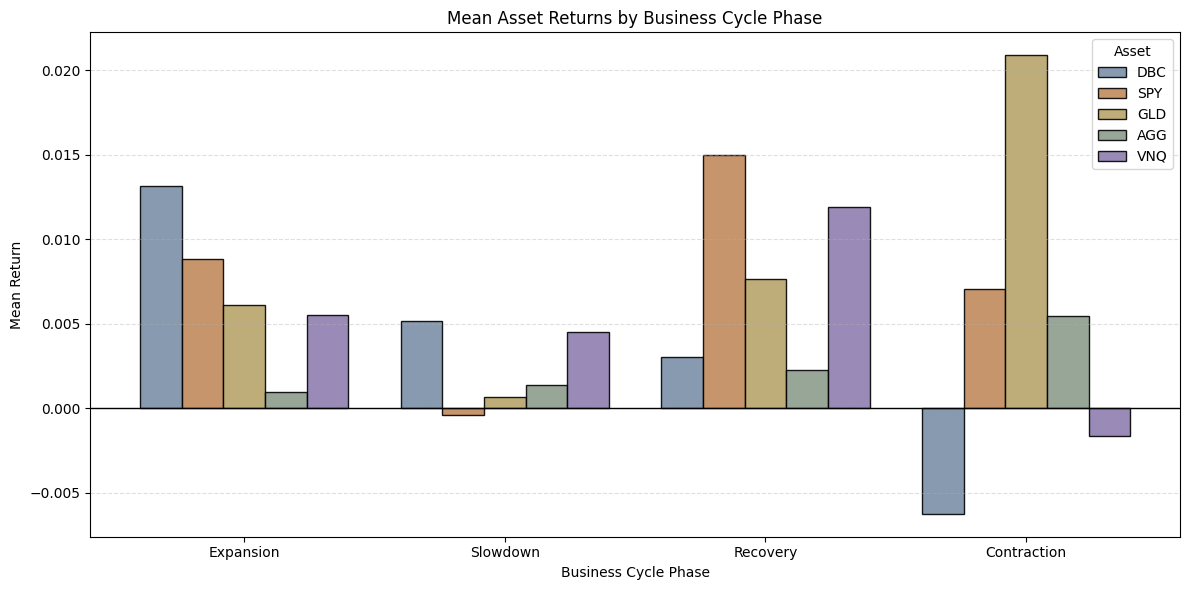

In [ ]:

# 12. Mean asset returns across business cycle phases

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

valid_phases = ["Expansion", "Slowdown", "Recovery", "Contraction"]
phase_return_cols = [f"{col}_phase_ret" for col in asset_cols]

# Compute mean returns by phase
mean_returns = (
    phase_returns.groupby("phase")[phase_return_cols]
    .mean()
    .reindex(valid_phases)
)

print("\n=== Mean returns by phase ===")
display(mean_returns.round(4))

# Prepare data for grouped bar chart
assets_clean = [col.replace("_phase_ret", "") for col in phase_return_cols]
x = np.arange(len(valid_phases))
width = 0.16

# Muted and more representative colors
asset_colors = {
    "DBC": "#7A8FA6",   # muted blue-grey
    "SPY": "#C08A5B",   # muted brown-orange
    "GLD": "#B7A46A",   # muted gold
    "AGG": "#8C9C8C",   # muted sage
    "VNQ": "#8E7DAF"    # muted lavender
}

fig, ax = plt.subplots(figsize=(12, 6))

for i, asset in enumerate(assets_clean):
    ax.bar(
        x + (i - 2) * width,
        mean_returns[f"{asset}_phase_ret"],
        width=width,
        label=asset,
        color=asset_colors[asset],
        edgecolor="black",
        alpha=0.9
    )

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(valid_phases)
ax.set_title("Mean Asset Returns by Business Cycle Phase")
ax.set_xlabel("Business Cycle Phase")
ax.set_ylabel("Mean Return")
ax.legend(title="Asset")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("mean_asset_returns_by_phase.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
#The results are broadly consistent with the economic intuition commonly found in the business cycle and asset allocation literature.
# US equities, represented by SPY, perform best in recovery and expansion phases, which is in line with the view that risky assets tend to benefit from improving growth expectations and stronger macroeconomic momentum.
#REITs, represented by VNQ, also show their strongest performance in recovery, which is plausible given their sensitivity to improving financial conditions and cyclical stabilization.
#Commodities, proxied by DBC, perform best in expansion, which fits the idea that commodity prices tend to strengthen in periods of above-trend growth and rising demand.
#Gold, represented by GLD, performs especially well in contraction, which is consistent with its role as a defensive or safe-haven asset during weaker macroeconomic conditions.
# Bonds, represented by AGG, remain positive across all phases and perform relatively well in contraction, which supports the standard view that high-quality fixed income tends to be more resilient in
#adverse economic environments.

#At the same time, the results also suggest that the phase-classification framework may have practical relevance for tactical asset allocation.
#If different asset classes systematically perform better in different OECD CLI phases, then the indicator can serve as a useful regime signal for tilting portfolio weights rather than maintaining a fully static allocation. In particular, the evidence points to a more pro-cyclical allocation toward equities, REITs, and commodities during recovery and expansion, and a more defensive tilt toward gold and bonds during contraction. However, these findings should be interpreted with caution, since the analysis is based on ex post revised CLI data and descriptive phase averages rather than a fully out-of-sample investment strategy. Even so, the results provide a reasonable empirical motivation for using business cycle phases as an input in tactical asset allocation decisions.